# Rating model — does the persona clustering help prediction?

**Goal.** Predict the rating (1–5) a user would give a movie **nobody has rated yet** (cold start problem), and find out which information about the user improves the prediction. In particular: does the persona clustering from `08` help, compared with using the user's rating statistics only?

The models form a ladder. Each step adds one thing to the previous one and answers one question:

| step | model | question |
|---|---|---|
| 1 | **Baseline:** movie features only | how far does TMDB metadata alone get? |
| 2 | + **user statistics** | how much do the user's rating habits (generous / harsh) add? |
| 3 | + **persona label** | does the clustering help, beyond the user statistics? |
| 4 | + **persona distances** | does a *soft* persona position help? |
| 5 | + **full taste profile** (no clustering) | does the user's individual taste help, and how much of it does the clustering keep? |

Steps 3–5 each add to step 2, so they can be compared directly. Step 5 is the final model.

Research questions answered here:
- How much does the error drop from the movie-only baseline to a personalized model, and does the persona add to it (section 5)?
- Which features drive the predictions?

## 1. Load

Outputs of `06`–`08`. Only users with a persona (≥ 20 training ratings) are modelled.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import HistGradientBoostingRegressor

PROCESSED = Path("../data/processed")
RANDOM_STATE = 42

movies = (
    pd.read_csv(PROCESSED / "movies_features.csv", usecols=lambda c: c != "cast_top5")
    .merge(pd.read_csv(PROCESSED / "movie_split.csv"), on="netflix_movie_id")
    .merge(pd.read_csv(PROCESSED / "track_records.csv"), on="netflix_movie_id")
    .set_index("netflix_movie_id")
)
user_stats = pd.read_csv(PROCESSED / "user_stats_train.csv").set_index("rater_id")
personas = pd.read_csv(PROCESSED / "user_personas.csv").set_index("rater_id")
persona_genre = pd.read_csv(PROCESSED / "persona_genre_scores.csv").set_index("persona")
profiles = pd.read_csv(PROCESSED / "user_profiles.csv").set_index("rater_id").add_prefix("taste_")
K = len(persona_genre)

GENRE_COLS = [c for c in movies.columns if c.startswith("genre_")]
COMPANY_COLS = [c for c in movies.columns if c.startswith("company_")]
print(f"movies: {movies['split'].value_counts().to_dict()} | users with persona: {len(personas):,} | personas: {K}")

c:\Users\yael\anaconda3\envs\pythonProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


movies: {'train': 919, 'test': 198, 'val': 197} | users with persona: 332,265 | personas: 5


## 2. Ratings of a sample of users

All ratings (training, validation and test movies) of a **random sample of 8,000 users** with a persona become the modelling rows, ~1.2M rows. A learning curve (1k → 8k users) showed the test error flattening out by 8k users: the limit is the ~1,100 training movies, not the number of users. `ratings.csv` is read in chunks.

In [2]:
N_USERS = 8_000
SPLITS = ["train", "val", "test"]

rng = np.random.default_rng(RANDOM_STATE)
sample_users = rng.choice(personas.index.to_numpy(), size=N_USERS, replace=False)

chunks = pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=["netflix_movie_id", "rater_id", "rating"],
    dtype={"netflix_movie_id": "int32", "rater_id": "int32", "rating": "int8"},
    chunksize=5_000_000,
)
data = pd.concat(
    (c[c["rater_id"].isin(sample_users) & c["netflix_movie_id"].isin(movies.index)] for c in chunks),
    ignore_index=True,
)
data["split"] = data["netflix_movie_id"].map(movies["split"])
parts = {s: data[data["split"] == s].reset_index(drop=True) for s in SPLITS}
del data
print("rows per split:", {s: len(p) for s, p in parts.items()})

rows per split: {'train': 816917, 'val': 185120, 'test': 175793}


**Is the sample representative?** The 8,000 users are compared with all 332k users with a persona: the share of each persona, the users' rating statistics (training movies), and how well their ratings cover the movies of each split.

**Result:** the sample matches all users closely. Persona shares differ by at most 0.6 percentage points, and the mean rating, number of ratings, rating spread and share of 4–5 stars have almost the same quartiles. The sample rates every validation and test movie and 918 of the 919 training movies, with a median of ~520–580 ratings per movie. A few movies have very few ratings in the sample (the rarest training movie has only 1).

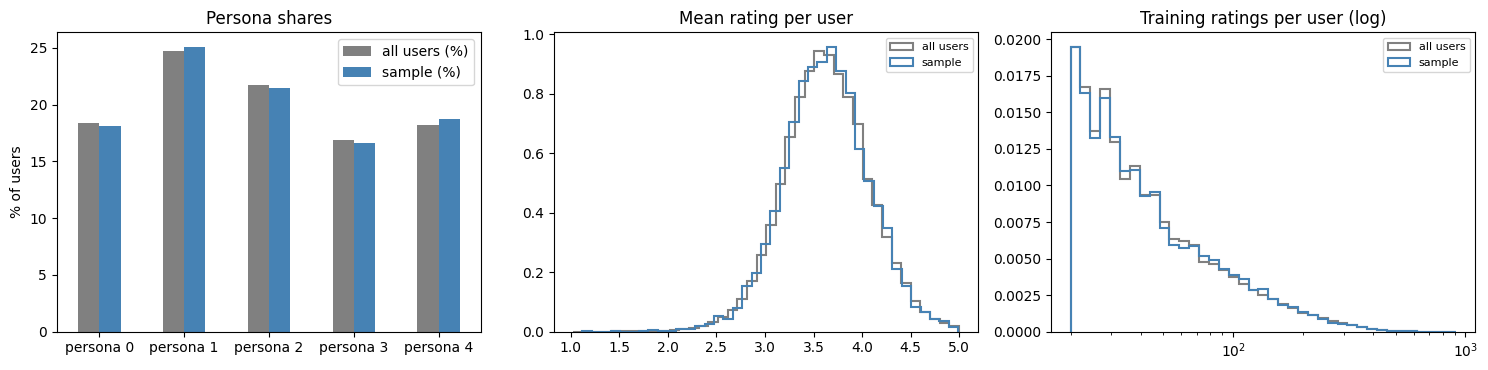

,all users (%),sample (%)
persona 0,18.4,18.1
persona 1,24.8,25.1
persona 2,21.7,21.4
persona 3,16.9,16.6
persona 4,18.2,18.8


all users                                 sample                       \
     user_mean user_n user_pct_ge4 user_std user_mean  user_n user_pct_ge4   
mean      3.63  103.0         0.58     0.98      3.63  102.11         0.58   
25%       3.34   36.0         0.46     0.82      3.35   36.00         0.46   
50%       3.62   69.0         0.58     0.96      3.63   70.00         0.58   
75%       3.92  137.0         0.71     1.11      3.92  136.00         0.71   

               
     user_std  
mean     0.97  
25%      0.83  
50%      0.96  
75%      1.11

,movies,rated by the sample,median ratings per movie,fewest ratings per movie
train,919.0,918.0,584.0,1.0
val,197.0,197.0,520.0,2.0
test,198.0,198.0,563.5,6.0


In [3]:
share = pd.DataFrame({
    "all users (%)": personas["persona_id"].value_counts(normalize=True),
    "sample (%)": personas.loc[sample_users, "persona_id"].value_counts(normalize=True),
}).sort_index().mul(100)
share.index = [f"persona {k}" for k in share.index]

STAT_COLS = ["user_n", "user_mean", "user_std", "user_pct_ge4"]
all_stats = user_stats.reindex(personas.index)[STAT_COLS]
sample_stats = user_stats.reindex(sample_users)[STAT_COLS]
stats_compare = pd.concat(
    {"all users": all_stats.describe().loc[["mean", "25%", "50%", "75%"]],
     "sample": sample_stats.describe().loc[["mean", "25%", "50%", "75%"]]},
).unstack(0).swaplevel(axis=1).sort_index(axis=1)

coverage = pd.DataFrame({
    s: {
        "movies": int((movies["split"] == s).sum()),
        "rated by the sample": parts[s]["netflix_movie_id"].nunique(),
        "median ratings per movie": parts[s]["netflix_movie_id"].value_counts().median(),
        "fewest ratings per movie": parts[s]["netflix_movie_id"].value_counts().min(),
    }
    for s in SPLITS
}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
share.plot.bar(ax=axes[0], rot=0, color=["gray", "steelblue"])
axes[0].set_ylabel("% of users")
axes[0].set_title("Persona shares")
for ax, col, title in [(axes[1], "user_mean", "Mean rating per user"), (axes[2], "user_n", "Training ratings per user (log)")]:
    bins = np.logspace(np.log10(all_stats[col].min()), np.log10(all_stats[col].max()), 40) if col == "user_n" else 40
    ax.hist(all_stats[col], bins=bins, density=True, histtype="step", color="gray", lw=1.5, label="all users")
    ax.hist(sample_stats[col], bins=bins, density=True, histtype="step", color="steelblue", lw=1.5, label="sample")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[2].set_xscale("log")
fig.tight_layout()
plt.show()
display(share.round(1), stats_compare.round(2), coverage)

## 3. Features

| group | features | source |
|---|---|---|
| **A. Movie** | `runtime`, `movie_age_log`, `log_roi`, 18 `genre_*`, 16 `company_*`, `us_only` / `us_coproduction` / `non_us`, `lang_en`, `is_multilingual`, `director_track_record`, `cast_track_record` | `06`, `07` |
| **B. User statistics** | `user_mean`, `user_std`, `user_n_log`, `user_pct_ge4` (share of 4–5 star ratings) | `07` |
| **C1. Persona label** | persona one-hot `persona_0…`, `persona_genre_score` (how far above / below their own average the user's persona rates the movie's genres) | `08` |
| **C2. Persona distances** | `dist_0…`: distance from the user's taste profile to each persona centre, a *soft* persona position | `08` |
| **D. Taste profile** | the 25 `taste_*` values the clustering was built on: for each genre and production feature, whether the user rates movies with more of it above or below their own average | `08` |

**Why the taste profile must be a feature.** Each row is one rating and holds no user id, so the model cannot see a user's other ratings. Without groups C or D, two users with the same statistics look identical to it. The taste profile summarizes the user's other ratings and puts that summary into every row of that user.

**Leakage.** Every statistic is computed from training movies only, so no feature of a test movie contains its rating. On a **training row**, the user statistics (B) would include the very rating being predicted, so that rating is removed from them (leave-one-out). The taste profile and persona of a training row still contain its own rating with a weight of ~1/70 (users have a median of ~70 training ratings). This can make training rows look slightly easier; the test evaluation is not affected.

In [4]:
MOVIE_COLS = (
    ["runtime", "movie_age_log", "log_roi"] + GENRE_COLS + COMPANY_COLS
    + ["us_only", "us_coproduction", "non_us", "lang_en", "is_multilingual"]
    + ["director_track_record", "cast_track_record"]
)
USER_COLS = ["user_mean", "user_std", "user_n_log", "user_pct_ge4"]
LABEL_COLS = [f"persona_{k}" for k in range(K)] + ["persona_genre_score"]
DIST_COLS = [f"dist_{k}" for k in range(K)]
TASTE_COLS = list(profiles.columns)


def build_features(df):
    movie = movies.reindex(df["netflix_movie_id"])
    X = pd.DataFrame(movie[MOVIE_COLS].to_numpy(dtype="float32"), columns=MOVIE_COLS)

    # B. user statistics, leave-one-out on training rows
    us = user_stats.reindex(df["rater_id"])
    n, mean, std, pct = (us[c].to_numpy() for c in ["user_n", "user_mean", "user_std", "user_pct_ge4"])
    own = (df["split"].to_numpy() == "train").astype(float)
    r = df["rating"].to_numpy(dtype=float)
    n_loo = n - own
    mean_loo = (n * mean - own * r) / n_loo
    sumsq_loo = (n - 1) * std**2 + n * mean**2 - own * r**2
    X["user_mean"] = mean_loo
    X["user_std"] = np.sqrt(np.maximum((sumsq_loo - n_loo * mean_loo**2) / (n_loo - 1), 0))
    X["user_n_log"] = np.log(n_loo)
    X["user_pct_ge4"] = (n * pct - own * (r >= 4)) / n_loo

    # C1. persona label, C2. persona distances
    pers = personas.reindex(df["rater_id"])
    persona = pers["persona_id"].to_numpy()
    for k in range(K):
        X[f"persona_{k}"] = (persona == k).astype("float32")
        X[f"dist_{k}"] = pers[f"dist_{k}"].to_numpy()
    genres = movie[GENRE_COLS].to_numpy()
    pg = persona_genre[[g.removeprefix("genre_") for g in GENRE_COLS]].to_numpy()[persona]
    X["persona_genre_score"] = (genres * pg).sum(axis=1) / np.maximum(genres.sum(axis=1), 1)

    # D. taste profile
    X[TASTE_COLS] = profiles.reindex(df["rater_id"]).to_numpy(dtype="float32")
    return X.astype("float32")


X = {s: build_features(p) for s, p in parts.items()}
y = {s: p["rating"].to_numpy(dtype="float32") for s, p in parts.items()}
print({s: X[s].shape for s in SPLITS})

{'train': (816917, 84), 'val': (185120, 84), 'test': (175793, 84)}


## 4. Models

All models are gradient-boosted trees (`HistGradientBoostingRegressor`). They handle mixed feature types and interactions without scaling, and they work with SHAP (section 6). Predictions are **continuous** numbers clipped to [1, 5]; the real ratings are whole stars.

**How the splits are used:**
1. **Tune** the tree size (`max_leaf_nodes`) on validation movies, using the final model (step 5), and reuse it for all models.
2. **Refit** all models on **train + validation movies** (~1,100 movies instead of ~900). This is safe because every feature of a validation movie is computed from training movies only.
3. **Evaluate** once on the test movies (section 5).

In [5]:
FEATURES = {
    "1 Baseline (movie only)": MOVIE_COLS,
    "2 + user statistics": MOVIE_COLS + USER_COLS,
    "3 + persona label": MOVIE_COLS + USER_COLS + LABEL_COLS,
    "4 + persona distances": MOVIE_COLS + USER_COLS + DIST_COLS,
    "5 + taste profile": MOVIE_COLS + USER_COLS + TASTE_COLS,
}
BASE, USER, FINAL = "1 Baseline (movie only)", "2 + user statistics", "5 + taste profile"


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def fit(cols, X_train, y_train, leaves):
    model = HistGradientBoostingRegressor(
        learning_rate=0.1, max_iter=300, max_leaf_nodes=leaves, min_samples_leaf=100,
        early_stopping=False, random_state=RANDOM_STATE,
    )
    # pass one float64 array: sklearn would otherwise keep both the float32 selection and its own float64 copy
    return model.fit(X_train[cols].to_numpy(dtype=np.float64), y_train)


def predict(model, X_part, cols):
    return np.clip(model.predict(X_part[cols].to_numpy(dtype=np.float64)), 1, 5)


tuning = {}
for leaves in [31, 127]:
    model = fit(FEATURES[FINAL], X["train"], y["train"], leaves)
    tuning[leaves] = rmse(y["val"], predict(model, X["val"], FEATURES[FINAL]))
BEST_LEAVES = min(tuning, key=tuning.get)
print("validation RMSE by max_leaf_nodes:", {k: round(v, 4) for k, v in tuning.items()}, "-> chosen", BEST_LEAVES)

validation RMSE by max_leaf_nodes: {31: 0.9406, 127: 0.9538} -> chosen 31


In [6]:
X_fit = pd.concat([X["train"], X["val"]], ignore_index=True)
y_fit = np.concatenate([y["train"], y["val"]])
global_mean = float(y_fit.mean())

models = {name: fit(cols, X_fit, y_fit, BEST_LEAVES) for name, cols in FEATURES.items()}

## 5. Evaluation on test movies

The test movies were not used for any choice above. Besides RMSE and MAE (in stars), two "right / wrong" views of each prediction:
- **exact star:** the prediction rounded to the nearest star equals the real rating. This is harsh for a model that predicts averages: always predicting "4" is already right 35% of the time.
- **within 1 star:** the prediction is at most 1 star from the real rating.

In [7]:
y_test = y["test"]
pred = {"0 Global mean": np.full(len(y_test), global_mean)}
pred |= {name: predict(model, X["test"], FEATURES[name]) for name, model in models.items()}

scores = pd.DataFrame({
    name: {
        "RMSE": rmse(y_test, p),
        "exact star (%)": 100 * np.mean(np.rint(p) == y_test),
        "within 1 star (%)": 100 * np.mean(np.abs(p - y_test) <= 1),
    }
    for name, p in pred.items()
}).T
scores["RMSE gain vs baseline (%)"] = 100 * (1 - scores["RMSE"] / scores.loc[BASE, "RMSE"])
print(f"test ratings: {len(y_test):,} | movies: {parts['test']['netflix_movie_id'].nunique()} | users: {parts['test']['rater_id'].nunique():,}")
scores.round(3)

test ratings: 175,793 | movies: 198 | users: 7,968


,RMSE,exact star (%),within 1 star (%),RMSE gain vs baseline (%)
0 Global mean,1.065,34.967,61.812,-2.026
1 Baseline (movie only),1.043,34.893,62.360,0.000
2 + user statistics,0.969,38.317,69.444,7.137
3 + persona label,0.969,38.509,69.442,7.111
4 + persona distances,0.962,38.705,69.808,7.761
5 + taste profile,0.957,39.427,70.579,8.274


**Is a difference real?** With only ~200 test movies, part of a small difference can come from which movies happen to be in the test set. A **bootstrap over movies** resamples the test movies with replacement 1,000 times and recomputes the RMSE difference between two models. If the 95% interval excludes 0, the improvement is reliable. Steps 3–5 are each compared with step 2 (user statistics only).

In [8]:
movie_codes, movie_pos = np.unique(parts["test"]["netflix_movie_id"], return_inverse=True)
n_per_movie = np.bincount(movie_pos)


def bootstrap_rmse_diff(model_a, model_b, n_boot=1000):
    """95% interval of RMSE(a) - RMSE(b) over resampled test movies."""
    sse_a = np.bincount(movie_pos, weights=(y_test - pred[model_a]) ** 2)
    sse_b = np.bincount(movie_pos, weights=(y_test - pred[model_b]) ** 2)
    boot_rng = np.random.default_rng(RANDOM_STATE)
    diffs = []
    for _ in range(n_boot):
        counts = np.bincount(boot_rng.integers(0, len(movie_codes), len(movie_codes)), minlength=len(movie_codes))
        n = counts @ n_per_movie
        diffs.append(np.sqrt(counts @ sse_a / n) - np.sqrt(counts @ sse_b / n))
    return np.percentile(diffs, [2.5, 97.5])


comparisons = [(USER, BASE)] + [(name, USER) for name in list(FEATURES)[2:]]
diffs = pd.DataFrame([
    {"model": a, "vs": b, "RMSE difference": rmse(y_test, pred[a]) - rmse(y_test, pred[b]),
     "low": lo, "high": hi, "reliable": hi < 0}
    for a, b in comparisons
    for lo, hi in [bootstrap_rmse_diff(a, b)]
]).set_index("model")
diffs.round(4)

,vs,RMSE difference,low,high,reliable
model,,,,,
2 + user statistics,1 Baseline (movie only),-0.0745,-0.0841,-0.0653,True
3 + persona label,2 + user statistics,0.0003,-0.0066,0.0078,False
4 + persona distances,2 + user statistics,-0.0065,-0.0135,0.0009,False
5 + taste profile,2 + user statistics,-0.0119,-0.0191,-0.0046,True


**(a) The ladder.** Left: test RMSE of each step. Right: what each persona / taste step adds **on top of the user statistics**, with its 95% interval. A bar whose interval crosses 0 is not a reliable improvement.

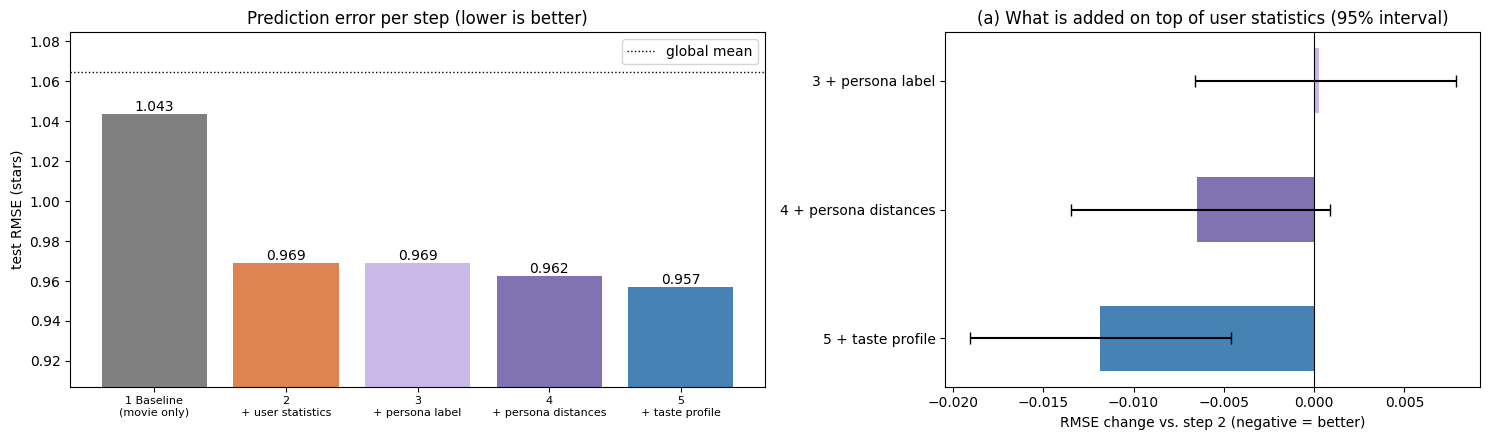

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})

colors = ["gray", "#dd8452", "#c9b8e8", "#8172b3", "steelblue"]
model_scores = scores.drop("0 Global mean")
bars = axes[0].bar(range(len(model_scores)), model_scores["RMSE"], color=colors)
axes[0].bar_label(bars, fmt="%.3f")
axes[0].axhline(scores.loc["0 Global mean", "RMSE"], color="black", ls=":", lw=1, label="global mean")
axes[0].set_xticks(range(len(model_scores)), [n.replace(" + ", "\n+ ").replace(" (", "\n(") for n in model_scores.index], fontsize=8)
axes[0].set_ylim(model_scores["RMSE"].min() - 0.05, scores["RMSE"].max() + 0.02)
axes[0].set_ylabel("test RMSE (stars)")
axes[0].set_title("Prediction error per step (lower is better)")
axes[0].legend()

added = diffs.iloc[1:]
ypos = np.arange(len(added))[::-1]
axes[1].barh(ypos, added["RMSE difference"], color=colors[2:], height=0.5)
axes[1].errorbar(added["RMSE difference"], ypos,
                 xerr=[added["RMSE difference"] - added["low"], added["high"] - added["RMSE difference"]],
                 fmt="none", color="black", capsize=4)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_yticks(ypos, added.index)
axes[1].set_xlabel("RMSE change vs. step 2 (negative = better)")
axes[1].set_title("(a) What is added on top of user statistics (95% interval)")
fig.tight_layout()
plt.show()

**Taste without user statistics.** The same three ways of describing taste, now added to the baseline alone, show how much taste information each keeps. The persona label is the most compressed (1 of 5 groups), the distances keep 5 numbers, and the taste profile keeps all 25.

In [10]:
taste_alone = {
    "movie + persona label": MOVIE_COLS + LABEL_COLS,
    "movie + persona distances": MOVIE_COLS + DIST_COLS,
    "movie + taste profile": MOVIE_COLS + TASTE_COLS,
}
alone = {BASE: scores.loc[BASE, "RMSE"]}
for name, cols in taste_alone.items():
    alone[name] = rmse(y_test, predict(fit(cols, X_fit, y_fit, BEST_LEAVES), X["test"], cols))
alone = pd.Series(alone, name="test RMSE").to_frame()
alone["gain vs baseline (%)"] = 100 * (1 - alone["test RMSE"] / alone.loc[BASE, "test RMSE"])
del X_fit
alone.round(4)

,test RMSE,gain vs baseline (%)
1 Baseline (movie only),1.0434,0.0000
movie + persona label,1.0443,-0.0867
movie + persona distances,1.0021,3.9551
movie + taste profile,0.9805,6.0256


**(b) Predicted vs. real rating.** Each box shows the predictions for the test ratings with that real star value. A good model's boxes climb from 1 to 5 stars. The baseline gives every user the same prediction for a movie, so it can only separate good and bad movies, not harsh and generous users. Even the final model's predictions stay closer to the middle than the real ratings: a squared-error model predicts the *expected* rating, and when the features explain only part of a rating, that expectation lies near the middle.

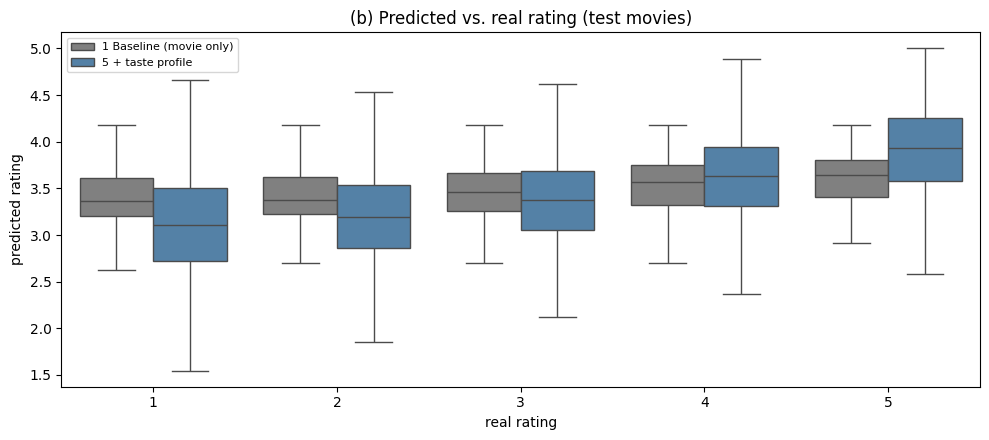

In [11]:
box = pd.concat([
    pd.DataFrame({"real rating": y_test.astype(int), "predicted rating": pred[name], "model": name})
    for name in [BASE, FINAL]
])
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=box, x="real rating", y="predicted rating", hue="model", showfliers=False,
            palette=["gray", "steelblue"], ax=ax)
ax.set_title("(b) Predicted vs. real rating (test movies)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**(c) Very poor predictions.** The number of test ratings each model misses by **more than 2 stars** (for example, predicting 3.5 for a 1-star rating), split by the real rating. These are the predictions a user would see as clearly wrong.

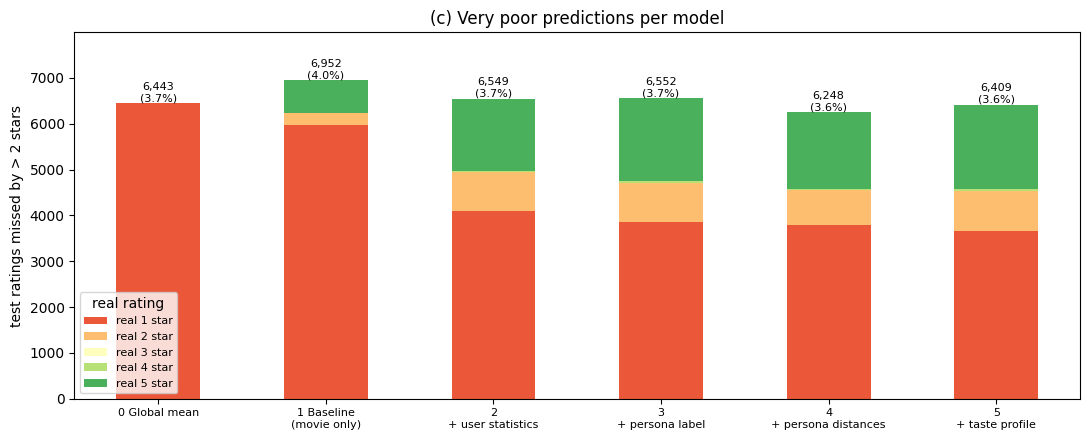

In [12]:
VERY_POOR = 2  # stars
poor = pd.DataFrame({
    name: pd.Series(y_test[np.abs(p - y_test) > VERY_POOR].astype(int)).value_counts()
    for name, p in pred.items()
}).T.reindex(columns=range(1, 6)).fillna(0).astype(int)
poor.columns = [f"real {r} star" for r in poor.columns]

ax = poor.plot.bar(stacked=True, figsize=(11, 4.5), rot=0, color=sns.color_palette("RdYlGn", 5))
for i, total in enumerate(poor.sum(axis=1)):
    ax.text(i, total, f"{total:,}\n({100 * total / len(y_test):.1f}%)", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(poor)), [n.replace(" + ", "\n+ ").replace(" (", "\n(") for n in poor.index], fontsize=8)
ax.set_ylim(0, poor.sum(axis=1).max() * 1.15)
ax.set_ylabel(f"test ratings missed by > {VERY_POOR} stars")
ax.set_title("(c) Very poor predictions per model")
ax.legend(title="real rating", fontsize=8)
plt.tight_layout()
plt.show()

**(d) Error per persona.** Test RMSE of the baseline and the final model for the users of each persona: does personalization help every persona, or some more than others?

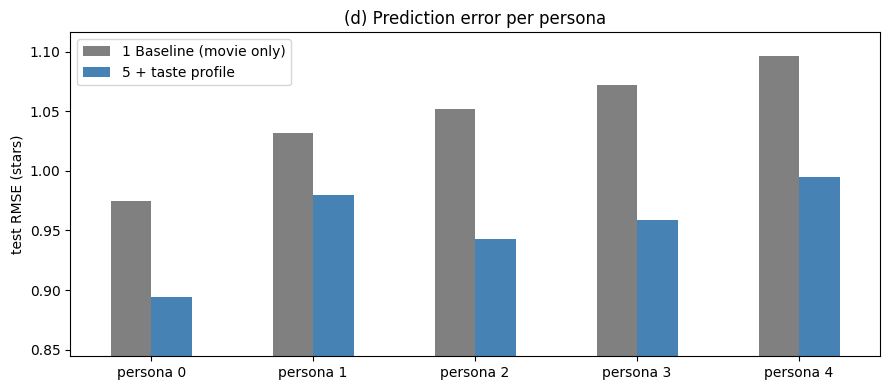

,1 Baseline (movie only),5 + taste profile,gain (%)
persona 0,0.975,0.895,8.221
persona 1,1.032,0.979,5.055
persona 2,1.052,0.942,10.417
persona 3,1.072,0.958,10.601
persona 4,1.096,0.995,9.215


In [13]:
test_persona = personas["persona_id"].reindex(parts["test"]["rater_id"]).to_numpy()
by_persona = pd.DataFrame({
    name: pd.Series((y_test - pred[name]) ** 2).groupby(test_persona).mean() ** 0.5 for name in [BASE, FINAL]
})
by_persona.index = [f"persona {k}" for k in by_persona.index]

ax = by_persona.plot.bar(color=["gray", "steelblue"], figsize=(9, 4), rot=0)
ax.set_ylim(by_persona.min().min() - 0.05, by_persona.max().max() + 0.02)
ax.set_ylabel("test RMSE (stars)")
ax.set_title("(d) Prediction error per persona")
plt.tight_layout()
plt.show()
by_persona.assign(**{"gain (%)": 100 * (1 - by_persona[FINAL] / by_persona[BASE])}).round(3)

## 6. What drives the predictions (RQ3) — SHAP

**SHAP values** split each prediction of the final model into a contribution per feature, in stars, relative to the average prediction. They are computed on a random sample of 10,000 test rows.
- **(e) Summary plot:** one dot per row, for the 15 most important features (by mean |SHAP|). The horizontal position shows how much the feature pushed that prediction up or down. The colour is the feature's value (red = high, blue = low).

SHAP shows what the model *uses*, not what *improves* predictions of new movies; the ladder above answers the second question.

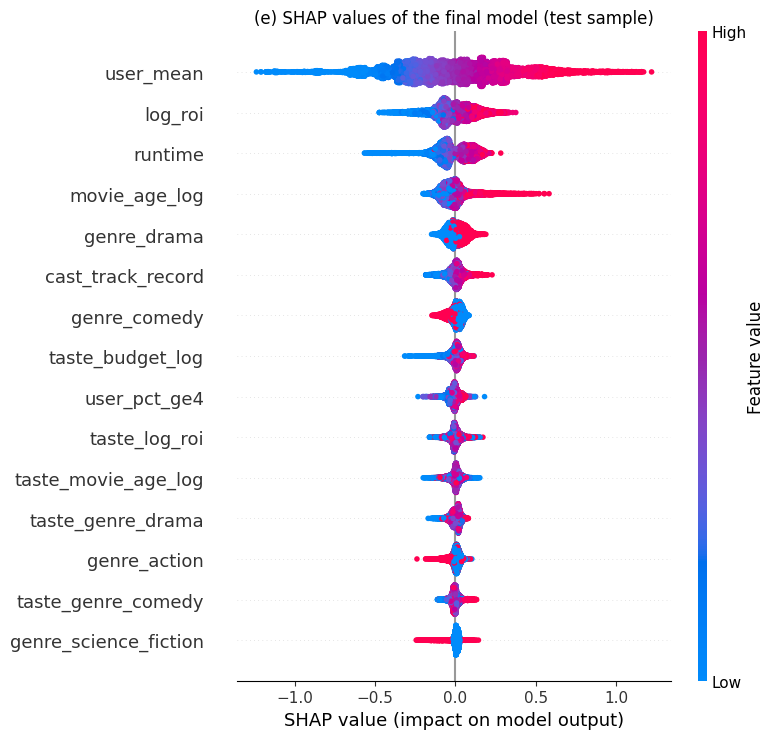

In [14]:
N_SHAP = 10_000
shap_idx = rng.choice(len(y_test), size=N_SHAP, replace=False)
X_shap = X["test"][FEATURES[FINAL]].iloc[shap_idx]
shap_values = shap.TreeExplainer(models[FINAL]).shap_values(X_shap.to_numpy(dtype=np.float64))

shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title("(e) SHAP values of the final model (test sample)")
plt.tight_layout()
plt.show()

**Observations**

**RQ4 — the ladder (test movies, 175,793 ratings).**

| step | test RMSE | gain vs. baseline | within 1 star |
|---|---|---|---|
| Global mean | 1.065 | −2.0% | 61.8% |
| 1 Baseline (movie only) | 1.043 | 0 | 62.4% |
| 2 + user statistics | 0.969 | 7.1% | 69.4% |
| 3 + persona label | 0.969 | 7.1% | 69.4% |
| 4 + persona distances | 0.962 | 7.8% | 69.8% |
| **5 + taste profile** | **0.957** | **8.3%** | **70.6%** |

- **Movie metadata alone helps only a little.** The baseline is just 2% better than the global mean. It gives every user the same prediction for a movie (flat boxes in (b)), and from TMDB metadata it can only roughly guess how good an unseen movie is.
- **The user's rating habits bring most of the gain** (−0.075 RMSE, 95% interval [−0.084, −0.065]). `user_mean` alone is by far the strongest feature (e).
- **The persona clustering does not help on top of the user statistics.** The persona label changes nothing (+0.000, interval [−0.007, +0.008]). The distances to the persona centres help a little (−0.007), but their interval includes 0 ([−0.014, +0.001]), so the gain is not reliable.
- **The user's individual taste does help.** The 25-value taste profile, the same input the clustering was built on, gives a reliable gain over the user statistics (−0.012, interval [−0.019, −0.005]).
- **The clustering compresses the taste away.** Added to the baseline without user statistics, the taste information gives: persona label −0.1%, persona distances 4.0%, full taste profile 6.0%. The more taste is compressed, the less of it is useful for prediction. This fits `08`: taste is a continuum (low silhouette), so 5 personas *describe* users well (RQ1) but lose the individual differences that predict ratings.
- **Every persona benefits** from personalization (d): the final model beats the baseline by 8–11% for four personas, and by 5% for persona 1 (*Arthouse & international*), whose taste is furthest from the mainstream movie features.
- **Predictions stay near the middle (b).** The final model gets 7 out of 10 ratings within 1 star, but 1-star and 5-star ratings are still predicted around 3 and 4. A squared-error model predicts the expected rating, and the features explain only part of an individual rating.
- **Personalization does not remove very poor predictions (c).** Every model misses 3.5–4% of the test ratings by more than 2 stars. The global mean misses only 1-star ratings. The personalized models miss fewer 1-star ratings (3,664 for step 5 vs. 5,977 for the baseline) but more 5-star ones (1,832 vs. 726): they push predictions towards each user's usual level, which helps on average but goes wrong when a user rates a movie far from their own habit. Step 4 has the fewest very poor predictions (6,248), step 5 a few more (6,409).

**RQ3 — what drives the predictions (SHAP).**
- **`user_mean`** dominates. Next come movie features: **`log_roi`** (commercial hits get higher predictions), **`runtime`** (short films lower), **`movie_age_log`** (older films higher: the old films still watched are the classics), drama (+), comedy (−), and the cast track record.
- The most used taste features are **`taste_budget_log`**, `taste_log_roi`, `taste_movie_age_log` and the drama / comedy tastes: production-style taste matters as much as genre taste.